# VectorDB Documents — Column Review

Review the structure and per-column content of:
- `VectorDB_Documents.json` (main collection)
- `VectorDBdev_Documents.json` (dev collection)

Both files are **MongoDB-export dumps**: a leading `[`, a trailing `]`, and pretty-printed JSON objects concatenated **without commas**. `json.load` does not accept this — the loader below uses `JSONDecoder.raw_decode` to stream-parse the records.

Each record has four top-level keys:
- `_id` — Mongo ObjectId wrapper (`{"$oid": "..."}`)
- `id` — integer primary key
- `vector_full_embeddings` — 1536-d float list
- `payload.metadata` — 19 metadata fields
- `payload.page_content` — text chunk

In [1]:
import json
from json import JSONDecoder
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_colwidth", 140)

ROOT = Path("..")
MAIN_PATH = ROOT / "VectorDB_Documents.json"
DEV_PATH  = ROOT / "VectorDBdev_Documents.json"

def load_concatenated_json(path: Path):
    """Parse a MongoDB-style dump: optional [ ... ] wrapper with comma-less concatenated objects."""
    text = Path(path).read_text(encoding="utf-8").strip()
    if text.startswith("["):
        text = text[1:]
    if text.endswith("]"):
        text = text[:-1]
    dec = JSONDecoder()
    i, n = 0, len(text)
    out = []
    while i < n:
        while i < n and text[i] in " \n\r\t,":
            i += 1
        if i >= n:
            break
        obj, end = dec.raw_decode(text, i)
        out.append(obj)
        i = end
    return out

main_records = load_concatenated_json(MAIN_PATH)
dev_records  = load_concatenated_json(DEV_PATH)
print(f"main : {len(main_records):,} records  ({MAIN_PATH.stat().st_size/1e6:.1f} MB)")
print(f"dev  : {len(dev_records):,} records  ({DEV_PATH.stat().st_size/1e6:.1f} MB)")

main : 648 records  (32.3 MB)
dev  : 187 records  (9.2 MB)


## 1. Flatten to DataFrames

Explode `payload.metadata` into top-level columns, keep `page_content` as a column, and keep the raw embedding vector in a dedicated column.  A `split` column tags each row as `main` or `dev`.

In [2]:
def records_to_df(records, split: str) -> pd.DataFrame:
    rows = []
    for r in records:
        payload  = r.get("payload", {}) or {}
        metadata = payload.get("metadata", {}) or {}
        row = {
            "split": split,
            "_id": (r.get("_id") or {}).get("$oid"),
            "id": r.get("id"),
            "embedding": r.get("vector_full_embeddings"),
            "page_content": payload.get("page_content"),
        }
        for k, v in metadata.items():
            row[f"meta.{k}"] = v
        rows.append(row)
    return pd.DataFrame(rows)

df_main = records_to_df(main_records, "main")
df_dev  = records_to_df(dev_records, "dev")
df      = pd.concat([df_main, df_dev], ignore_index=True)

print(f"Combined shape: {df.shape}")
print(f"\nColumns ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c}")

Combined shape: (835, 24)

Columns (24):
  split
  _id
  id
  embedding
  page_content
  meta.id
  meta.parent_id
  meta.node_level
  meta.document_id
  meta.node_source
  meta.document_type
  meta.document_status
  meta.page_number
  meta.is_header
  meta.has_requirements
  meta.bounding_boxes
  meta.document_url
  meta.image_url
  meta.path_to_item
  meta.content_summary
  meta.keywords
  meta.level_summary
  meta.2D_embeddings_content_summary
  meta.2D_embeddings


## 2. Schema overview

Per column: dtype, non-null count, unique-value count, and one example value — separately for main vs dev so you can spot schema drift.

In [3]:
def short_preview(val, maxlen=80):
    if val is None:
        return ""
    if isinstance(val, list):
        return f"list[{len(val)}]" + (f" e.g. {val[:2]}" if val else "")
    if isinstance(val, dict):
        return f"dict{list(val.keys())}"
    s = str(val).replace("\n", " ")
    return s if len(s) <= maxlen else s[:maxlen] + "…"

def column_summary(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for c in frame.columns:
        s = frame[c]
        non_null = s.notna().sum()
        try:
            n_unique = s.nunique(dropna=True)
        except TypeError:  # unhashable (lists/dicts)
            n_unique = "—"
        sample = s.dropna().iloc[0] if non_null else None
        rows.append({
            "column": c,
            "dtype": str(s.dtype),
            "non_null": int(non_null),
            "null": int(len(s) - non_null),
            "n_unique": n_unique,
            "example": short_preview(sample),
        })
    return pd.DataFrame(rows).set_index("column")

print("── MAIN ──")
display(column_summary(df_main))
print("── DEV ──")
display(column_summary(df_dev))

── MAIN ──


,dtype,non_null,null,n_unique,example
column,,,,,
split,str,648,0,1,main
_id,str,648,0,648,69b5b4c6b274814a8c7d0fce
id,int64,648,0,648,61
embedding,object,648,0,—,"list[1536] e.g. [-0.0065331789664924145, 0.00866491999477148]"
page_content,str,648,0,633,"Art. D15. < DRW 2006-03-16/45, art. 2, 002; En vigueur : 06-04-2006> § 1er. L'au…"
meta.id,int64,648,0,648,61
meta.parent_id,object,648,0,—,58
meta.node_level,int64,648,0,7,10
meta.document_id,int64,648,0,2,2


── DEV ──


,dtype,non_null,null,n_unique,example
column,,,,,
split,str,187,0,1,dev
_id,str,187,0,187,69ba85966f97479299a39997
id,int64,187,0,187,4224
embedding,object,187,0,—,"list[1536] e.g. [-0.005686233285814524, 0.018982190638780594]"
page_content,str,187,0,173,"<!-- PageHeader=""Docu 53885"" -->"
meta.id,int64,187,0,187,4224
meta.parent_id,object,187,0,—,dict['$numberDouble']
meta.node_level,int64,187,0,4,10
meta.document_id,int64,187,0,2,45


## 3. ID and `_id` sanity

Check uniqueness of `id` within each split, and whether dev is a subset / disjoint set of main.

In [4]:
main_ids = set(df_main["id"])
dev_ids  = set(df_dev["id"])
main_oids = set(df_main["_id"])
dev_oids  = set(df_dev["_id"])

print("── id ──")
print(f"main:  n={len(df_main):>4}  unique id={len(main_ids):>4}  "
      f"range=[{df_main['id'].min()}, {df_main['id'].max()}]")
print(f"dev :  n={len(df_dev):>4}  unique id={len(dev_ids):>4}  "
      f"range=[{df_dev['id'].min()}, {df_dev['id'].max()}]")
print(f"main ∩ dev ids : {len(main_ids & dev_ids)}")
print(f"dev ⊆ main     : {dev_ids.issubset(main_ids)}")
print(f"main ∪ dev ids : {len(main_ids | dev_ids)}")

print("\n── _id ($oid) ──")
print(f"main unique _id: {len(main_oids)}  | dev unique _id: {len(dev_oids)}")
print(f"main ∩ dev _id : {len(main_oids & dev_oids)}")

── id ──
main:  n= 648  unique id= 648  range=[2, 649]
dev :  n= 187  unique id= 187  range=[4224, 4410]
main ∩ dev ids : 0
dev ⊆ main     : False
main ∪ dev ids : 835

── _id ($oid) ──
main unique _id: 648  | dev unique _id: 187
main ∩ dev _id : 0


## 4. Embeddings

Dimensionality, any NaN/None entries, vector-norm distribution, and whether any two records are exact duplicates (suggests re-embedding of identical text).

In [5]:
def embedding_stats(frame: pd.DataFrame, label: str):
    lens = frame["embedding"].apply(lambda v: len(v) if isinstance(v, list) else 0)
    any_missing = frame["embedding"].isna().sum()
    dims = lens.value_counts().to_dict()
    arr = np.asarray(frame["embedding"].tolist(), dtype=np.float32)
    norms = np.linalg.norm(arr, axis=1)
    nan_rows = int(np.isnan(arr).any(axis=1).sum())
    # Duplicate detection on first 32 dims (cheap proxy)
    sigs = [tuple(np.round(v[:32], 6)) for v in arr]
    dup_sigs = len(sigs) - len(set(sigs))
    print(f"── {label} ──")
    print(f"  records                : {len(frame):,}")
    print(f"  embedding length dist  : {dims}")
    print(f"  missing / None         : {any_missing}")
    print(f"  rows with NaN in vec   : {nan_rows}")
    print(f"  L2 norm  min/mean/max  : {norms.min():.6f} / {norms.mean():.6f} / {norms.max():.6f}")
    print(f"  likely duplicate vecs  : {dup_sigs} (matching first 32 dims)")
    return arr, norms

main_arr, main_norms = embedding_stats(df_main, "main")
print()
dev_arr,  dev_norms  = embedding_stats(df_dev, "dev")

all_norms = np.concatenate([main_norms, dev_norms])
lo, hi = float(all_norms.min()), float(all_norms.max())
if hi - lo < 1e-6:
    print(f"\nAll vectors are L2-normalised (norm ≈ {all_norms.mean():.6f}); "
          f"norm histogram skipped.")
else:
    pad = max((hi - lo) * 0.05, 1e-6)
    bins = np.linspace(lo - pad, hi + pad, 41)
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(main_norms, bins=bins, alpha=0.6, label="main", color="#4878d0")
    ax.hist(dev_norms,  bins=bins, alpha=0.6, label="dev",  color="#ee854a")
    ax.set_xlabel("L2 norm")
    ax.set_ylabel("records")
    ax.set_title("Embedding L2-norm distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

── main ──
  records                : 648
  embedding length dist  : {1536: 648}
  missing / None         : 0
  rows with NaN in vec   : 0
  L2 norm  min/mean/max  : 1.000000 / 1.000000 / 1.000000
  likely duplicate vecs  : 1 (matching first 32 dims)

── dev ──
  records                : 187
  embedding length dist  : {1536: 187}
  missing / None         : 0
  rows with NaN in vec   : 0
  L2 norm  min/mean/max  : 1.000000 / 1.000000 / 1.000000
  likely duplicate vecs  : 7 (matching first 32 dims)

All vectors are L2-normalised (norm ≈ 1.000000); norm histogram skipped.


## 5. `page_content` — length & samples

content_char_len                                                     \
                 count        mean          std   min   10%    25%    50%   
split                                                                       
dev              187.0  386.946524   492.504132  10.0  31.6  60.50  215.0   
main             648.0  756.052469  1020.794078   8.0  46.0  96.75  409.5   

                               ... content_word_len                        \
          75%     90%     95%  ...              std  min  10%   25%   50%   
split                          ...                                          
dev    451.50  1010.4  1358.7  ...        74.957000  2.0  5.0   9.5  33.0   
main   963.25  1948.9  2649.5  ...       158.987704  2.0  7.0  14.0  61.0   

                                            
         75%    90%    95%     99%     max  
split                                       
dev     73.5  150.0  204.6  338.74   518.0  
main   151.0  297.6  404.6  840.18  1191.0  

[2 rows x 24 columns]

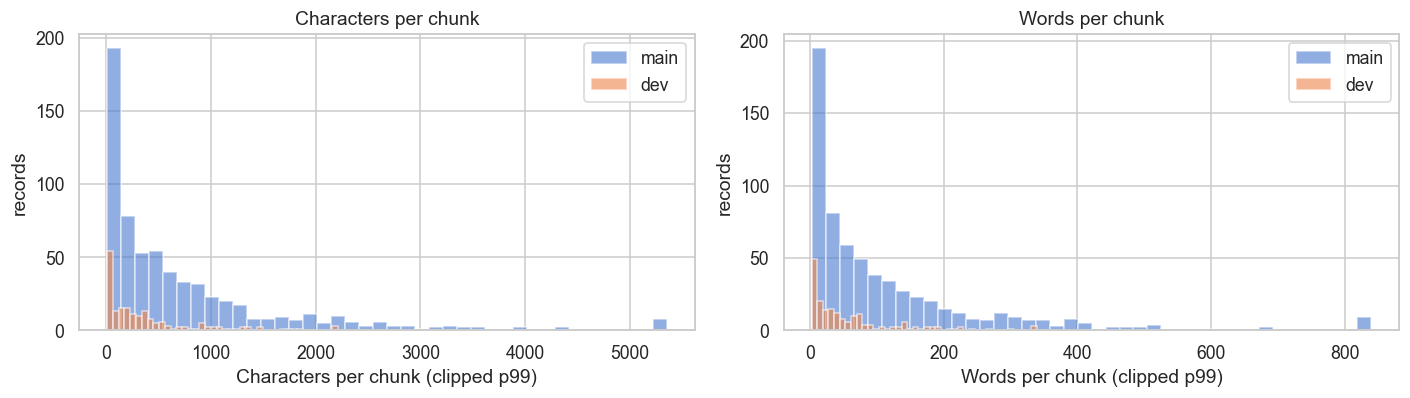

── Shortest 3 chunks (main) ──
  id=53  len=8  'Art. D9.'
  id=628  len=11  '## ANNEXES.'
  id=154  len=12  'Art. D28-20.'

── Longest 3 chunks (main) — first 200 chars ──
  id=348  len=7525  Art. D94.[1 Au sens de la présente partie, il faut entendre par : 1º "dommage environnemental" : a. les dommages causés aux espèces et habitats naturels proteges, à savoir tout dommage qui affecte sig…
  id=416  len=6313  Art. D141.[2 § 1.]2 [1 Pour l'application de la présente partie, l'on entend par : 1º [2 l'Administration : le Service public de Wallonie Agriculture, Ressources naturelles et Environnement; ]2 2º [2 …
  id=49  len=6247  Art. D6.[1 Au sens du présent Code, il faut entendre par : 1° auteur du plan ou du programme : l'autorité qui initie l'élaboration d'un plan ou d'un programme ou, à défaut, l'autorité compétente; 2° a…


In [6]:
df["content_char_len"] = df["page_content"].fillna("").str.len()
df["content_word_len"] = df["page_content"].fillna("").str.split().str.len()

pcts = [0, 10, 25, 50, 75, 90, 95, 99, 100]
summary = (
    df.groupby("split")[["content_char_len", "content_word_len"]]
      .describe(percentiles=[p/100 for p in pcts if 0 < p < 100])
)
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, col, title in zip(axes, ["content_char_len", "content_word_len"],
                          ["Characters per chunk", "Words per chunk"]):
    for split, color in [("main", "#4878d0"), ("dev", "#ee854a")]:
        vals = df.loc[df["split"] == split, col]
        ax.hist(vals.clip(upper=vals.quantile(0.99)), bins=40,
                alpha=0.6, label=split, color=color)
    ax.set_xlabel(title + " (clipped p99)")
    ax.set_ylabel("records")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()

print("── Shortest 3 chunks (main) ──")
for _, r in df_main.assign(l=df_main["page_content"].str.len()).nsmallest(3, "l").iterrows():
    print(f"  id={r['id']}  len={len(r['page_content'] or '')}  {r['page_content']!r}")
print("\n── Longest 3 chunks (main) — first 200 chars ──")
for _, r in df_main.assign(l=df_main["page_content"].str.len()).nlargest(3, "l").iterrows():
    txt = (r["page_content"] or "")[:200].replace("\n", " ")
    print(f"  id={r['id']}  len={len(r['page_content'] or '')}  {txt}…")

## 6. Metadata — per-column breakdown

Every `meta.*` field, value counts (top 10) and null rate. Low-cardinality fields show the full distribution; high-cardinality fields show only the most frequent values.

In [7]:
meta_cols = [c for c in df.columns if c.startswith("meta.")]

def describe_metadata_column(col: str):
    s = df[col]
    # Normalize unhashables (lists/dicts) to JSON strings so value_counts works
    def _norm(v):
        if isinstance(v, (list, dict)):
            return json.dumps(v, ensure_ascii=False)[:120]
        return v
    s_norm = s.map(_norm)
    null_rate = s_norm.isna().mean()
    n_unique  = s_norm.nunique(dropna=True)
    print(f"\n── {col}   (null={null_rate:.1%}, unique={n_unique}) ──")
    if n_unique == 0:
        print("  (all null)")
        return
    vc = s_norm.value_counts(dropna=False).head(10)
    by_split = (
        df.assign(_v=s_norm)
          .groupby(["split", "_v"], dropna=False).size()
          .unstack("split", fill_value=0)
    )
    top = by_split.loc[vc.index] if set(vc.index).issubset(by_split.index) else by_split.head(10)
    display(top)

for c in meta_cols:
    describe_metadata_column(c)


── meta.id   (null=0.0%, unique=835) ──


split,dev,main
meta.id,,
61,0,1
62,0,1
64,0,1
66,0,1
68,0,1
70,0,1
72,0,1
74,0,1
76,0,1



── meta.parent_id   (null=0.0%, unique=167) ──


split,dev,main
meta.parent_id,,
286,0,34
457,0,27
628,0,21
134,0,20
266,0,19
609,0,18
71,0,16
418,0,14
36,0,13



── meta.node_level   (null=0.0%, unique=7) ──


...

split,dev,main
meta.level_summary,,
,154,515
"Public authorities must organise and provide clear, objective environmental information they hold, and actively and systematically disseminate it using information and electronic technologies when available. Electronic publication need not include information collected before this title’s entry into force unless already in electronic form, and authorities should progressively make data available in electronic databases accessible via public telecom networks. At minimum authorities should publish treaties, legislation, policies, plans and their implementation reports (if electronic), state of the environment reports, monitoring data or summaries, permits with significant environmental impact (or where to find them), and environmental impact studies and risk assessments (or where to find them); the Government may define additional items and modalities. Authorities are deemed to comply if they link to sites where information is available. If aware of an imminent threat to health or the environment, authorities must promptly inform at-risk persons of any information that can help prevent or limit harm.",0,1
The exceptions set out in Articles D.18 §1 and D.19 §1 apply to the obligations imposed by this chapter.,0,1
"Establishes a regional network of Centres Régionaux d'Initiation à l'Environnement (CRIE) in Wallonia to inform, raise awareness and train the public on environmental matters. Defines ""asbl"" (non‑profit association) and ""CRIE"" and requires government allocation of CRIE sites according to geographic balance, natural‑heritage interest and population density. Each CRIE must promote environmental knowledge to youth, adults, schools, families and administrations by developing/distributing educational methodology and materials, organizing activities, workshops and training, and must specialize in at least one environmental discipline. The government approves asbl managers by a set procedure and may withdraw approval; approval lasts three years and is renewable. To qualify, an asbl’s purpose must match the CRIE objectives, its board must include at least two pedagogical and two scientific members, its project must meet CRIE missions, and its finances must be sound. The government provides required real estate and equipment, grants an annual subsidy per centre, sets payment modalities, and performs administrative follow‑up, control and annual evaluation based on activity and financial reports. A committee of accompaniment is instituted to ensure coherence, evaluate CRIE activities and advise the government in the approval procedure.",0,1
"Title II/1 establishes a system for recognizing and structurally funding environmental associations in the Walloon Region. It defines key terms, creates three recognition categories (federation/network, regional, local) granted for six years, and sets general eligibility (primary environmental purpose, Belgian HQ and Walloon activity, no disqualifying convictions, ≥3 years activity, auditable accounts, liability insurance) plus category-specific annual minimum activity thresholds and territorial scopes. Applications (including joint and federated applications) must follow Government-prescribed content and be filed via a single electronic portal in the first quarter; electronic submissions meeting IT integrity and timestamp requirements have equal probative force to registered mail. The Government may grant multiannual structural subsidies (three-year grants) to recognized associations and certain cooperative social enterprises based on the quality and feasibility of their environmental action plan(s); subsidies fund operating costs linked to plan implementation, are lump-sum, non-duplicative, may be indexed, and subject to Government rules. Payment is phased (30% on notification, subsequent tranches contingent on reports and proof of expenditure, final 10% after full accounting); small grants (<€2,500) may use a sworn declaration in lieu of det


── meta.2D_embeddings_content_summary   (null=0.0%, unique=835) ──


split,dev,main
meta.2D_embeddings_content_summary,,
"[82.07318878173828, 63.512088775634766]",0,1
"[81.52203369140625, 70.70011138916016]",0,1
"[80.06755065917969, 70.144775390625]",0,1
"[81.99053192138672, 71.25183868408203]",0,1
"[81.95877075195312, 73.92131042480469]",0,1
"[82.57188415527344, 79.80852508544922]",0,1
"[83.66241455078125, 72.33942413330078]",0,1
"[81.63528442382812, 68.86787414550781]",0,1
"[83.07190704345703, 68.44692993164062]",0,1



── meta.2D_embeddings   (null=0.0%, unique=835) ──


split,dev,main
meta.2D_embeddings,,
"[61.687923431396484, 46.600685119628906]",0,1
"[61.1883544921875, 45.632179260253906]",0,1
"[61.77857208251953, 46.72358322143555]",0,1
"[59.544395446777344, 43.608089447021484]",0,1
"[62.24134826660156, 43.25441360473633]",0,1
"[63.22634506225586, 42.88663864135742]",0,1
"[52.450439453125, 57.45958709716797]",0,1
"[61.716190338134766, 45.91579818725586]",0,1
"[58.9477424621582, 40.99102020263672]",0,1


## 7. Metadata cross-tabs

A few likely-interesting two-way breakdowns of low-cardinality fields.

In [8]:
def safe_crosstab(a: str, b: str):
    if a not in df.columns or b not in df.columns:
        return
    print(f"\n── {a}  ×  {b} ──")
    display(pd.crosstab(df[a], df[b], margins=True, dropna=False))

for a, b in [
    ("meta.document_type",   "meta.document_status"),
    ("meta.document_type",   "meta.is_header"),
    ("meta.node_level",      "meta.is_header"),
    ("meta.has_requirements","meta.document_type"),
    ("split",                "meta.document_type"),
    ("split",                "meta.document_status"),
]:
    safe_crosstab(a, b)


── meta.document_type  ×  meta.document_status ──


meta.document_status,Effective,All
meta.document_type,,
Regulation,835,835
All,835,835



── meta.document_type  ×  meta.is_header ──


meta.is_header,False,True,All
meta.document_type,,,
Regulation,669,166,835
All,669,166,835



── meta.node_level  ×  meta.is_header ──


...

meta.document_type,Regulation,All
meta.has_requirements,,
False,835,835
All,835,835



── split  ×  meta.document_type ──


meta.document_type,Regulation,All
split,,
dev,187,187
main,648,648
All,835,835



── split  ×  meta.document_status ──


meta.document_status,Effective,All
split,,
dev,187,187
main,648,648
All,835,835


## 8. `node_level` & `page_number` distributions

Histograms for the numeric metadata fields.

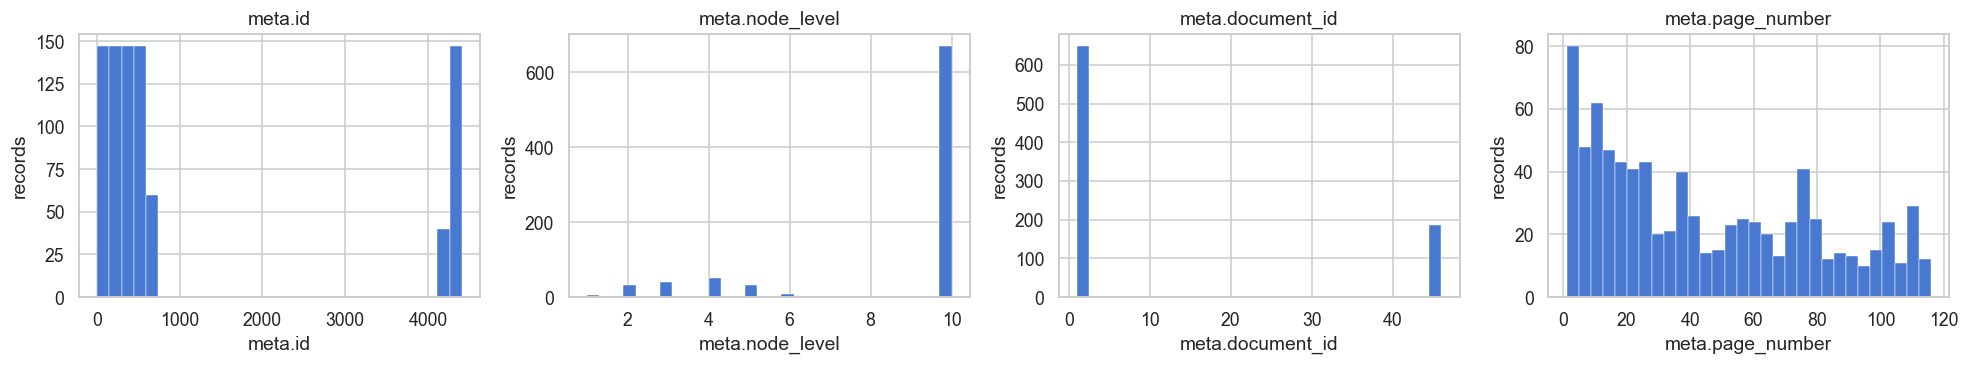

In [9]:
numeric_meta = [
    c for c in ["meta.id", "meta.node_level", "meta.document_id", "meta.page_number"]
    if c in df.columns
]

n = len(numeric_meta)
if n:
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 3.5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, numeric_meta):
        vals = pd.to_numeric(df[col], errors="coerce").dropna()
        ax.hist(vals, bins=30, color="#4878d0", edgecolor="white", linewidth=0.3)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("records")
    plt.tight_layout()
    plt.show()

## 9. Record inspector

Set `INSPECT_SPLIT` and `INSPECT_ID` to view a single record (all fields, truncated embedding).

In [10]:
INSPECT_SPLIT = "main"   # "main" or "dev"
INSPECT_ID    = None     # int id; leave None to pick the first record of the split

subset = df_main if INSPECT_SPLIT == "main" else df_dev
if INSPECT_ID is None:
    row = subset.iloc[0]
else:
    match = subset[subset["id"] == INSPECT_ID]
    row = match.iloc[0] if len(match) else None

if row is None:
    print(f"No record with id={INSPECT_ID} in {INSPECT_SPLIT}")
else:
    print(f"split={INSPECT_SPLIT}  id={row['id']}  _id={row['_id']}")
    emb = row["embedding"]
    print(f"embedding: dim={len(emb)}  first 5 = {emb[:5]}\n")
    print("── metadata ──")
    for c in [c for c in row.index if c.startswith("meta.")]:
        print(f"  {c:42s} {short_preview(row[c], 120)}")
    print("\n── page_content ──")
    print(row["page_content"])

split=main  id=61  _id=69b5b4c6b274814a8c7d0fce
embedding: dim=1536  first 5 = [-0.0065331789664924145, 0.00866491999477148, 0.0024010827764868736, -0.020785298198461533, -0.025580894201993942]

── metadata ──
  meta.id                                    61
  meta.parent_id                             58
  meta.node_level                            10
  meta.document_id                           2
  meta.node_source                           LIVRE 1ER DISPOSITIONS COMMUNES ET GÉNÉRALES (PARTIE DÉCRÉTALE)
  meta.document_type                         Regulation
  meta.document_status                       Effective
  meta.page_number                           12
  meta.is_header                             False
  meta.has_requirements                      False
  meta.bounding_boxes                        list[1] e.g. [{'pageNumber': 12, 'polygon': [0.4488, 6.0225, 7.5516, 6.0225, 7.5516, 8.2609, 0.4488, 8.2609]}]
  meta.document_url                          https://regaistoragenpd.blob

## 10. Export a flat CSV view (optional)

Drops the 1536-d embedding and writes a human-reviewable CSV next to the source JSON files. Large-file storage rules still apply — if these outputs grow, move them into `output/` (the OneDrive junction).

In [11]:
EXPORT = False   # set to True to write CSVs

if EXPORT:
    flat = df.drop(columns=["embedding"]).copy()
    # Stringify any list/dict metadata so CSV round-trips cleanly
    for c in flat.columns:
        if flat[c].map(lambda v: isinstance(v, (list, dict))).any():
            flat[c] = flat[c].map(lambda v: json.dumps(v, ensure_ascii=False) if isinstance(v, (list, dict)) else v)
    out_path = ROOT / "vectordb_documents_flat.csv"
    flat.to_csv(out_path, index=False, encoding="utf-8")
    print(f"Wrote {out_path}  ({out_path.stat().st_size/1e6:.2f} MB, {len(flat):,} rows)")